# GTSRB — Data Exploration
Steps covered:
1. Download dataset
2. Inspect folder structure
3. Class distribution
4. Visualise sample images
5. Image size distribution

In [1]:
import random
import sys
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from torchvision.datasets import GTSRB

sys.path.insert(0, str(Path("..").resolve()))

## 1. Download Dataset

In [2]:
DATA_ROOT = Path("../data/gtsrb")
DATA_ROOT.mkdir(parents=True, exist_ok=True)

train_dataset = GTSRB(root=DATA_ROOT, split="train", download=True)
test_dataset = GTSRB(root=DATA_ROOT, split="test", download=True)

print(f"Train samples : {len(train_dataset)}")
print(f"Test samples  : {len(test_dataset)}")

100%|███████████████████████████████████████████████████████| 187M/187M [00:19<00:00, 9.49MB/s]
100%|█████████████████████████████████████████████████████| 89.0M/89.0M [00:08<00:00, 11.1MB/s]
100%|██████████████████████████████████████████████████████| 99.6k/99.6k [00:00<00:00, 187kB/s]


Train samples : 26640
Test samples  : 12630


## 2. Inspect Folder Structure

In [4]:
training_root = DATA_ROOT / "gtsrb" / "GTSRB" / "Training"
class_folders = sorted(training_root.iterdir())

print(f"Number of class folders: {len(class_folders)}\n")
print(f"{'Folder':<10} {'Images':>8}")
print("-" * 20)
for folder in class_folders[:10]:
    n = len(list(folder.glob("*.ppm")))
    print(f"{folder.name:<10} {n:>8}")
print("... (showing first 10)")

Number of class folders: 44

Folder       Images
--------------------
00000           150
00001          1500
00002          1500
00003           960
00004          1320
00005          1260
00006           300
00007           960
00008           960
00009           990
... (showing first 10)


## 3. Class Distribution

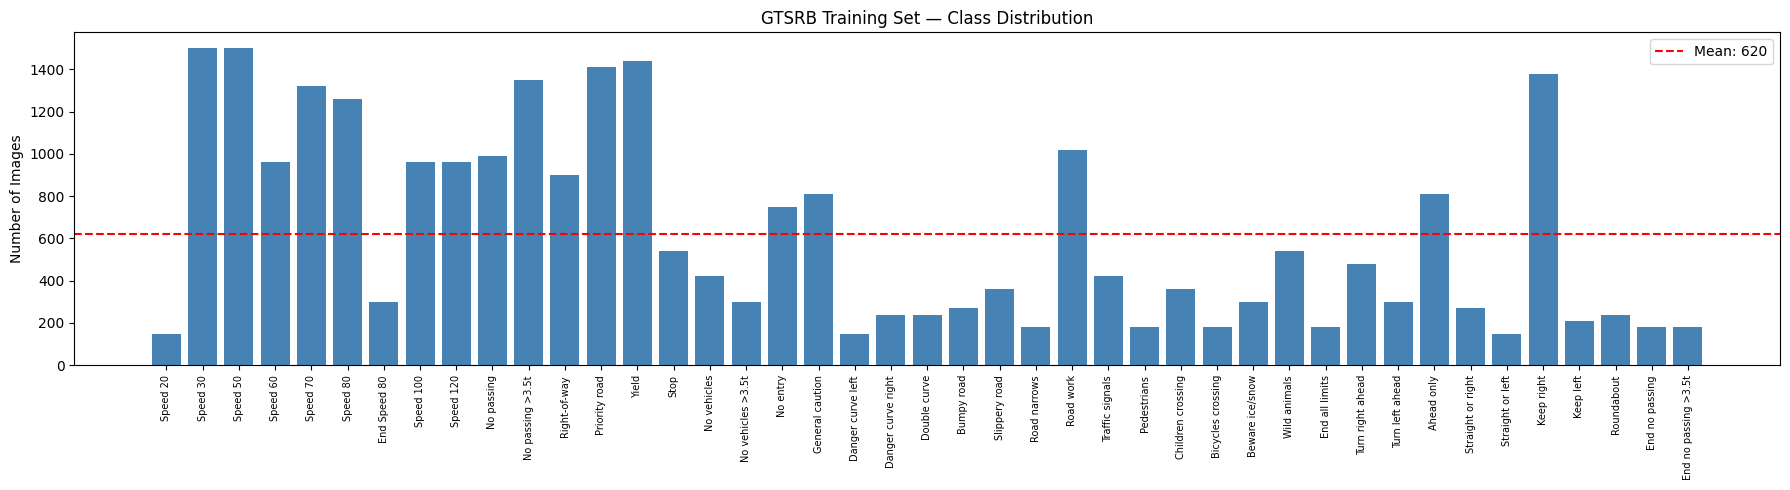

Most common  : class 01 (Speed 30) — 1500 images
Least common : class 00 (Speed 20) — 150 images
Imbalance ratio : 10.0x


In [5]:
CLASS_NAMES = [
    "Speed 20",
    "Speed 30",
    "Speed 50",
    "Speed 60",
    "Speed 70",
    "Speed 80",
    "End Speed 80",
    "Speed 100",
    "Speed 120",
    "No passing",
    "No passing >3.5t",
    "Right-of-way",
    "Priority road",
    "Yield",
    "Stop",
    "No vehicles",
    "No vehicles >3.5t",
    "No entry",
    "General caution",
    "Danger curve left",
    "Danger curve right",
    "Double curve",
    "Bumpy road",
    "Slippery road",
    "Road narrows",
    "Road work",
    "Traffic signals",
    "Pedestrians",
    "Children crossing",
    "Bicycles crossing",
    "Beware ice/snow",
    "Wild animals",
    "End all limits",
    "Turn right ahead",
    "Turn left ahead",
    "Ahead only",
    "Straight or right",
    "Straight or left",
    "Keep right",
    "Keep left",
    "Roundabout",
    "End no passing",
    "End no passing >3.5t",
]

labels = [label for _, label in train_dataset]
counts = Counter(labels)
class_counts = [counts[i] for i in range(43)]

fig, ax = plt.subplots(figsize=(18, 5))
ax.bar(range(43), class_counts, color="steelblue")
ax.axhline(
    np.mean(class_counts),
    color="red",
    linestyle="--",
    label=f"Mean: {np.mean(class_counts):.0f}",
)
ax.set_xticks(range(43))
ax.set_xticklabels(CLASS_NAMES, rotation=90, fontsize=7)
ax.set_ylabel("Number of Images")
ax.set_title("GTSRB Training Set — Class Distribution")
ax.legend()
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150)
plt.show()

most = int(np.argmax(class_counts))
least = int(np.argmin(class_counts))
print(
    f"Most common  : class {most:02d} ({CLASS_NAMES[most]}) — {class_counts[most]} images"
)
print(
    f"Least common : class {least:02d} ({CLASS_NAMES[least]}) — {class_counts[least]} images"
)
print(f"Imbalance ratio : {class_counts[most] / class_counts[least]:.1f}x")

## 4. Visualise Sample Images

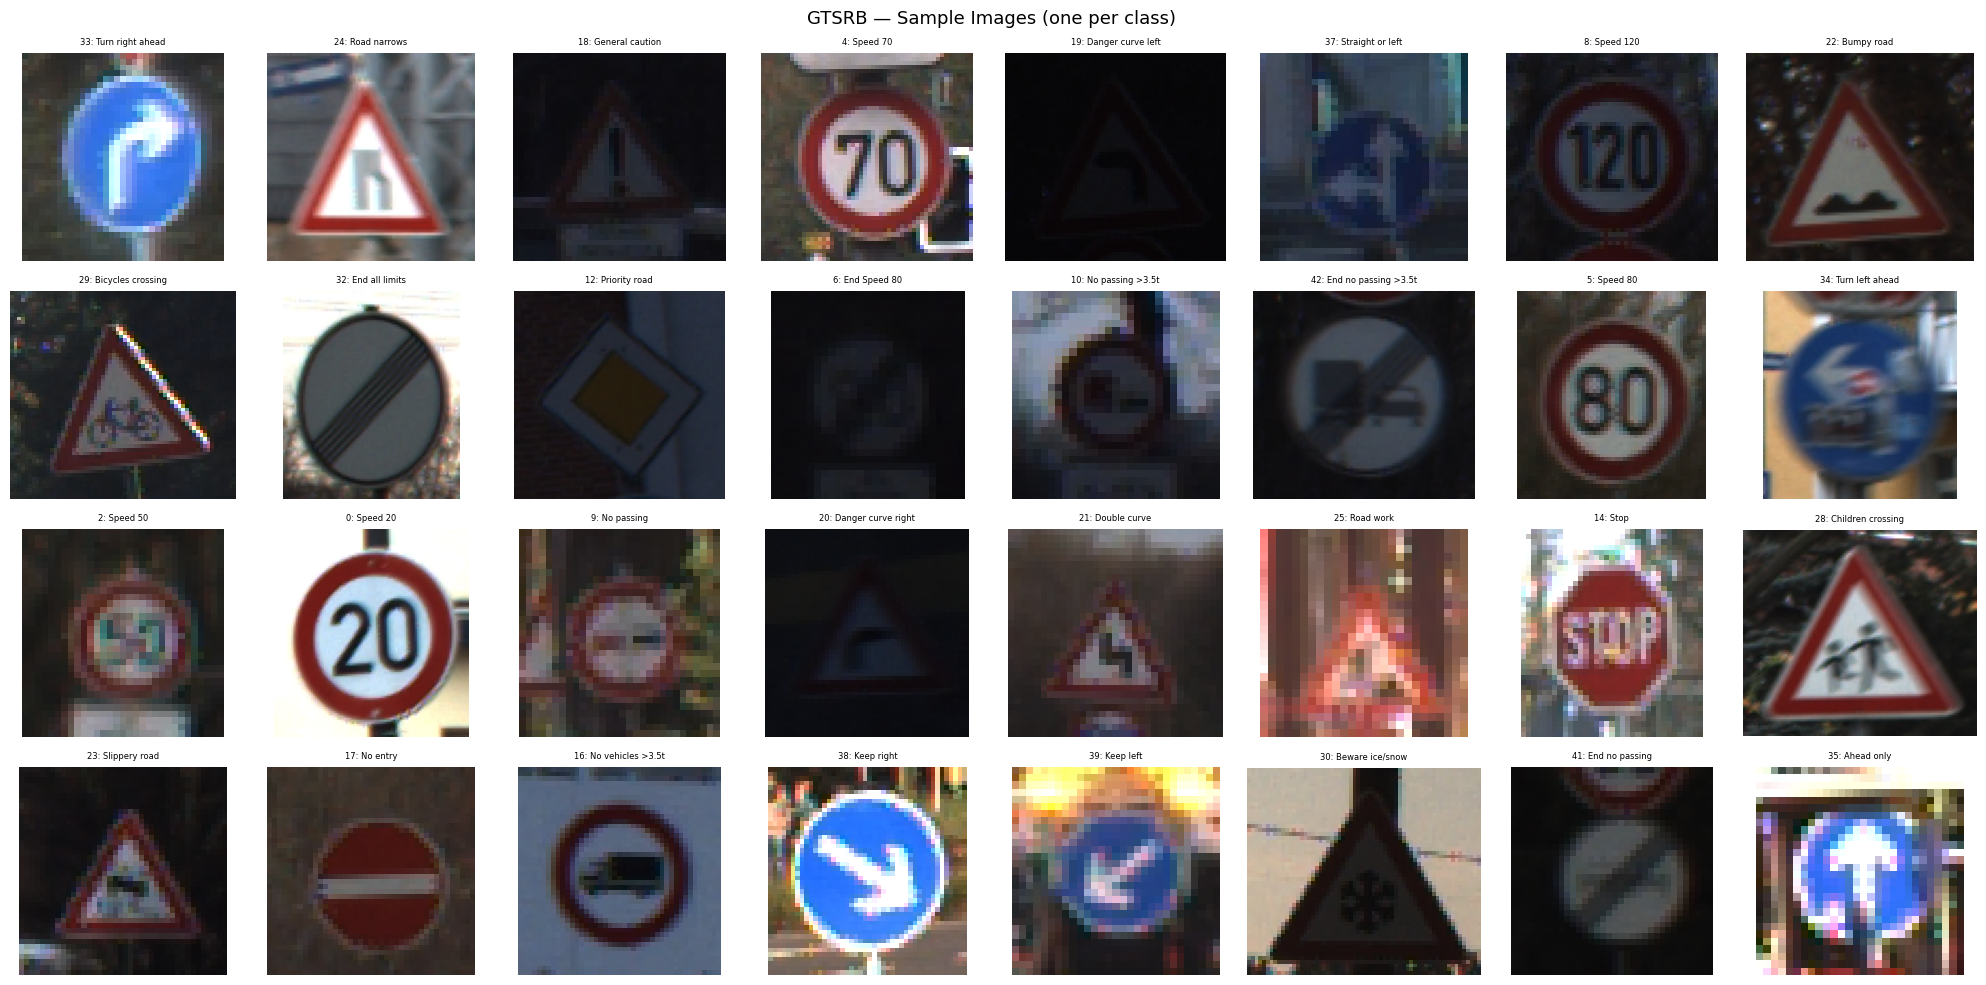

In [6]:
fig, axes = plt.subplots(4, 8, figsize=(20, 10))
axes = axes.flatten()

sample_classes = random.sample(range(43), 32)
for ax, class_id in zip(axes, sample_classes):
    folder = training_root / f"{class_id:05d}"
    img_path = random.choice(list(folder.glob("*.ppm")))
    img = Image.open(img_path)
    ax.imshow(img)
    ax.set_title(f"{class_id}: {CLASS_NAMES[class_id]}", fontsize=6)
    ax.axis("off")

plt.suptitle("GTSRB — Sample Images (one per class)", fontsize=13)
plt.tight_layout()
plt.savefig("sample_images.png", dpi=150)
plt.show()

## 5. Image Size Distribution

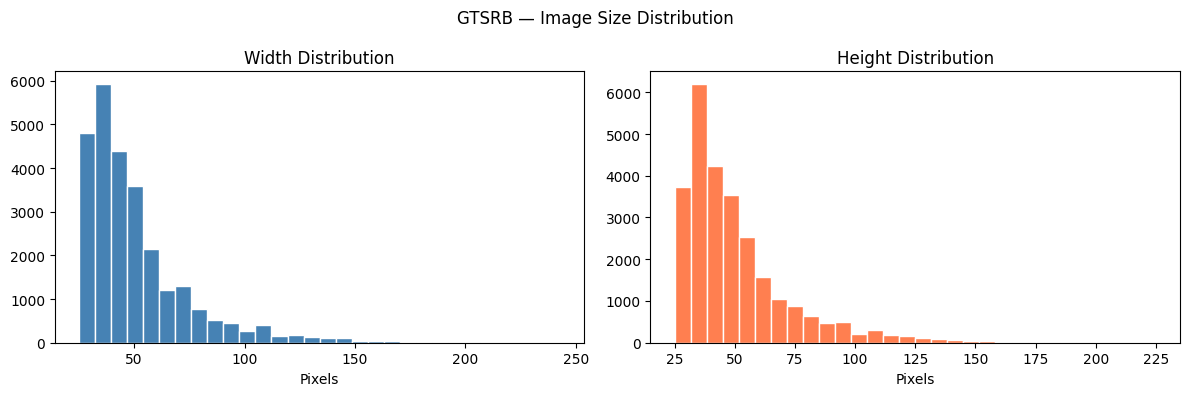

Width  — min: 25px  max: 243px  mean: 51px
Height — min: 25px  max: 225px  mean: 50px

Conclusion: resize all images to 224x224 (standard ImageNet input size)


In [ ]:
widths, heights = [], []

for img_path in training_root.rglob("*.ppm"):
    w, h = Image.open(img_path).size
    widths.append(w)
    heights.append(h)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(widths, bins=30, color="steelblue", edgecolor="white")
axes[0].set_title("Width Distribution")
axes[0].set_xlabel("Pixels")
axes[1].hist(heights, bins=30, color="coral", edgecolor="white")
axes[1].set_title("Height Distribution")
axes[1].set_xlabel("Pixels")
plt.suptitle("GTSRB — Image Size Distribution")
plt.tight_layout()
plt.savefig("size_distribution.png", dpi=150)
plt.show()

print(
    f"Width  — min: {min(widths)}px  max: {max(widths)}px  mean: {np.mean(widths):.0f}px"
)
print(
    f"Height — min: {min(heights)}px  max: {max(heights)}px  mean: {np.mean(heights):.0f}px"
)
print("\nConclusion: resize all images to 224x224 (standard ImageNet input size)")